In [1]:
%load_ext rich
%load_ext autoreload
%autoreload 2

In [2]:
import logging
import os
from functools import partial

import astropy.units as u
import matplotlib.pyplot as plt  # type: ignore
import numpy as np
from joblib import Parallel, delayed
from pixell import curvedsky
from tqdm.auto import tqdm

from notebooks.ksw_joblib import KSW_joblib
from scripts import core  # note the small c to import the core module and not the class

from scripts import Core
from scripts.utils import remove_mono_dipole, setup_logging
from scripts.utils.plots import plot_cl_alm, plot_patches

# Monkey patch the core module
core.KSW = KSW_joblib

logger = setup_logging(__name__, level=logging.DEBUG, use_rich=True)
logging.getLogger("matplotlib").setLevel(logging.WARNING)
logging.getLogger("healpy").setLevel(logging.WARNING)

## Setup

In [3]:
s = Core(
    [
        "settings/planck.json",
        "--nsims",
        "1",
        "--narray",
        "1",
        # "--polarizations",
        # "T",
        # "E",
    ]
)
s.is_main_job = True  # fix an issue with missing slurm job array

24-Apr-24 14:49:25 - scripts.core - DEBUG - Parsing CLI args: ['settings/planck.json', '--nsims', '1',  ]8;id=130505;file:///users/stevensonb/Research/MLPNG/scripts/core.py\core.py]8;;\:]8;id=851561;file:///users/stevensonb/Research/MLPNG/scripts/core.py#122\122]8;;\
'--narray', '1']                                                                                                   

24-Apr-24 14:49:25 - scripts.core - INFO - Loading settings from file settings/planck.json              ]8;id=501311;file:///users/stevensonb/Research/MLPNG/scripts/core.py\core.py]8;;\:]8;id=13652;file:///users/stevensonb/Research/MLPNG/scripts/core.py#149\149]8;;\

24-Apr-24 14:49:25 - scripts.core - DEBUG - Forcing setting 'nsims' to '1' due to CLI                   ]8;id=218287;file:///users/stevensonb/Research/MLPNG/scripts/core.py\core.py]8;;\:]8;id=578572;file:///users/stevensonb/Research/MLPNG/scripts/core.py#156\156]8;;\

24-Apr-24 14:49:25 - scripts.core - DEBUG - Forcing setting 'narray' to '1' due to CLI                  ]8;id=524886;file:///users/stevensonb/Research/MLPNG/scripts/core.py\core.py]8;;\:]8;id=257189;file:///users/stevensonb/Research/MLPNG/scripts/core.py#156\156]8;;\

24-Apr-24 14:49:25 - scripts.core - DEBUG - Found non-default value for 'cosmo_params': {'H0': 67.4,    ]8;id=669308;file:///users/stevensonb/Research/MLPNG/scripts/core.py\core.py]8;;\:]8;id=833853;file:///users/stevensonb/Research/MLPNG/scripts/core.py#263\263]8;;\
'As': 2.457e-09, 'ns': 0.9649, 'ombh2': 0.0224, 'omch2': 0.12, 'tau': 0.054, 'max_l': 2500, 'lmax':                
2000} (default: {'As': 2.13e-09, 'ns': 0.9624, 'pivot_scalar': 0.05, 'max_l': 1000, 'lmax': 500})                  

...

24-Apr-24 14:50:23 - scripts.core - DEBUG - Setting 'plot_dir' not found, using default: 'plots'        ]8;id=979869;file:///users/stevensonb/Research/MLPNG/scripts/core.py\core.py]8;;\:]8;id=669489;file:///users/stevensonb/Research/MLPNG/scripts/core.py#259\259]8;;\

24-Apr-24 14:50:23 - scripts.core - DEBUG - Setting 'tb_dir' not found, using default: 'tensorboard'    ]8;id=706735;file:///users/stevensonb/Research/MLPNG/scripts/core.py\core.py]8;;\:]8;id=255150;file:///users/stevensonb/Research/MLPNG/scripts/core.py#259\259]8;;\

24-Apr-24 14:50:23 - scripts.core - DEBUG - Setting 'model_dir' not found, using default: 'models'      ]8;id=196997;file:///users/stevensonb/Research/MLPNG/scripts/core.py\core.py]8;;\:]8;id=89375;file:///users/stevensonb/Research/MLPNG/scripts/core.py#259\259]8;;\

24-Apr-24 14:50:23 - scripts.core - DEBUG - Setting 'alm_dir' not found, using default: 'alms'          ]8;id=624269;file:///users/stevensonb/Research/MLPNG/scripts/core.py\core.py]8;;\:]8;id=797219;file:///users/stevensonb/Research/MLPNG/scripts/core.py#259\259]8;;\

24-Apr-24 14:50:23 - scripts.core - DEBUG - Setting 'patch_dir' not found, using default: 'patches'     ]8;id=295192;file:///users/stevensonb/Research/MLPNG/scripts/core.py\core.py]8;;\:]8;id=307731;file:///users/stevensonb/Research/MLPNG/scripts/core.py#259\259]8;;\

## Alm

In [4]:
from scripts.almgen import generate_alm_ng

This code generates the alms

$$a_{\ell m} = a_{\ell m}^{{G}} + f_{NL}^X a_{\ell m}^{NG}$$
with
$$a_{\ell m}^{NG,loc'} = \int dr r^2 \left[ \alpha_\ell(r)\left(\int d^2 \hat{n} Y_{\ell m}^\star (\hat{n}) B(r,\hat{n})^2 \right)\right]$$
and
$$\alpha_\ell(r)=\frac{2}{\pi} \int_0^\infty dk k^2 \Delta_\ell^T(k) j_\ell(k r)$$
$$\beta_\ell(r)=\frac{2}{\pi} \int_0^\infty dk k^{-1} \Delta_\phi \Delta_\ell^T(k) j_\ell(k r)$$
$$B(r, \hat{n}) = \sum_{\ell,m} \frac{\beta_\ell (r)}{C_\ell} a_{\ell m} Y_{\ell m}$$
where $\Delta_\phi$ is primordial normalization, $\Delta_\ell^T(k)$ is the transfer function, $j_\ell(k r)$ are the spherical bessel functions   

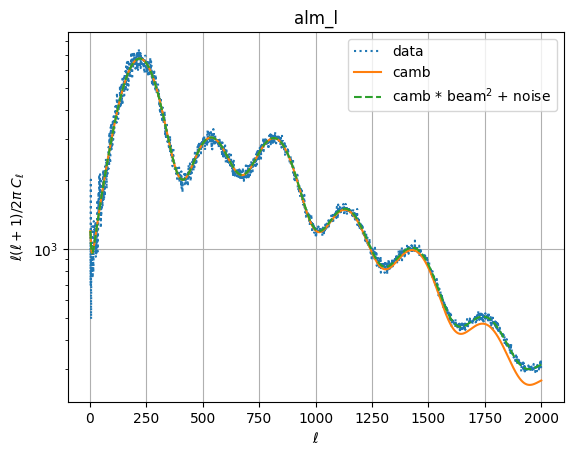

24-Apr-24 14:51:15 - scripts.almgen - INFO - Starting Alm_ng generation                                ]8;id=966033;file:///users/stevensonb/Research/MLPNG/scripts/almgen.py\almgen.py]8;;\:]8;id=995253;file:///users/stevensonb/Research/MLPNG/scripts/almgen.py#62\62]8;;\

24-Apr-24 14:51:15 - scripts.almgen - DEBUG - Using temp folder for Alm_ng generation:                 ]8;id=9510;file:///users/stevensonb/Research/MLPNG/scripts/almgen.py\almgen.py]8;;\:]8;id=448493;file:///users/stevensonb/Research/MLPNG/scripts/almgen.py#71\71]8;;\
/lustre/scratch/client/users/stevensonb                                                                            

Alm_ng:   0%|          | 0/1 [00:00<?, ?it/s]

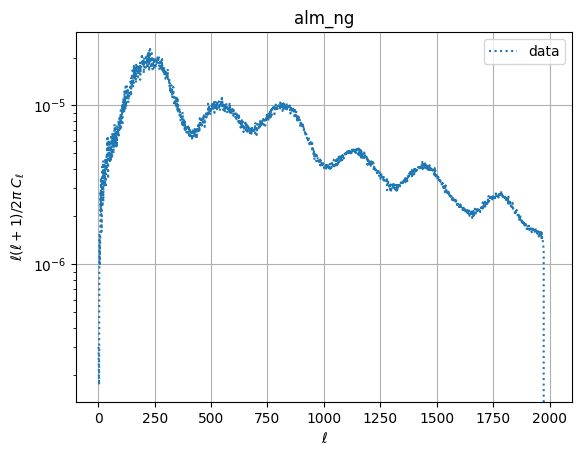

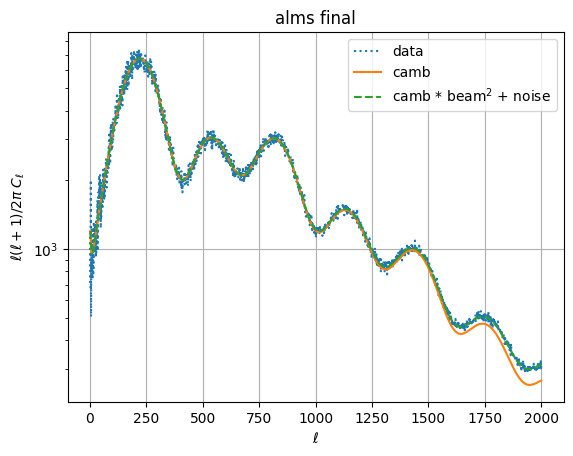

In [5]:
alm_l = np.array(
    [s.data.compute_alm_sim(s.lensing) for _ in range(s.nsims)],
    dtype=s.c_dtype,
)
plot_cl_alm(
    alm_l[0, 0],
    title="alm_l",
    plot_camb=True,
    c_ells=s.c_ells,
    camb_noise=True,
    noise=s.noise_ell[0],
    beam_width=s.beam_width,
)
fnls = s.rng.uniform(s.fnl_min, s.fnl_max, s.fnl_shape)
alm_ng = generate_alm_ng(s, alm_l)
plot_cl_alm(alm_ng[0, 0], title="alm_ng")
alms = alm_l + fnls * alm_ng
alms = remove_mono_dipole(alms)
plot_cl_alm(
    alms[0, 0],
    title="alms final",
    plot_camb=True,
    c_ells=s.c_ells,
    camb_noise=True,
    noise=s.noise_ell[0],
    beam_width=s.beam_width,
)

24-Apr-24 14:52:47 - __main__ - INFO - (1, 1, 2003001)                                              ]8;id=418485;file:///tmp/ipykernel_2449164/1095838917.py\1095838917.py]8;;\:]8;id=310911;file:///tmp/ipykernel_2449164/1095838917.py#2\2]8;;\

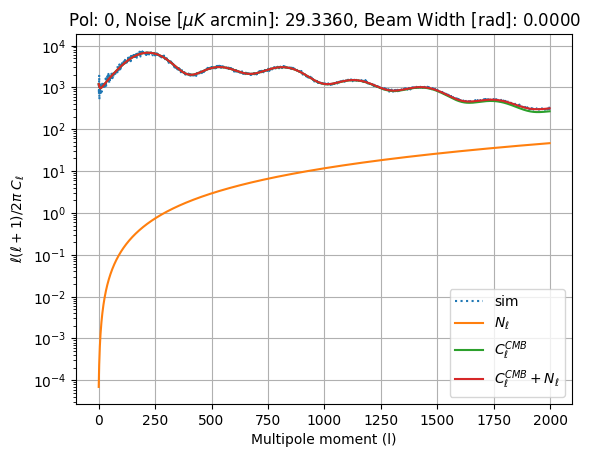

In [7]:
for pol in range(s.npol):
    logger.info(alms.shape)
    ells = np.arange(2, s.nell)
    scale = ells * (ells + 1) / 2 / np.pi
    N_ell = s.noise_ell[pol, 2:]
    cl_cmb = s.c_ells[2 : s.nell, pol]
    cl_sim = curvedsky.alm2cl(alms[0, pol])[2 : s.nell]
    beam = s.beam_ell[pol, 2:]

    plot_func = plt.semilogy
    plot_func(scale * cl_sim, label=r"sim", linestyle=":")
    plot_func(scale * N_ell, label=r"$N_\ell$")
    plot_func(scale * cl_cmb, label=r"$C_{\ell}^{CMB}$")
    plot_func(scale * (cl_cmb * beam**2 + N_ell), label=r"$C_\ell^{CMB} + N_\ell$")
    plt.legend()
    plt.xlabel("Multipole moment (l)")
    plt.ylabel(r"$\ell(\ell+1)/2\pi\;C_{\ell}$")
    plt.grid(True)
    # plt.ylim([3e2, 4e4])
    noise_muk2arcmin = (s.noise_scale_tt * u.radian).to_value(u.arcmin)
    plt.title(
        f"Pol: {pol}, Noise [$\\mu K$ arcmin]: {noise_muk2arcmin:.4f}, Beam Width [rad]: {s.beam_width:.4f}"
    )
    plt.show()

## PatchGen

In [8]:
from scripts.patchgen import cutSqPatches_lenspyx, cutSqPatches_pixell, get_fs_patch_geo

In [9]:
# Here we get the geometry of our patches in a tuple
patch_geo = get_fs_patch_geo(s)

# we also setup the cutPatches function to use either pixell or lenspyx
# depending on if we are doing lensing or not, and provide a lot of
# arguments that are needed and will stay constant
# we cannot abuse the python scope here since these will need to be pickled
common_settings = [
    s.lmax,
    s.plot_dir,
    s.base_name,
    s.npatches,
    s.c_ells,
    *patch_geo,
]
if s.lensing:
    max_l = s.cosmo_params["max_l"]
    cl_phi = s.cosmo._camb_data.get_lens_potential_cls(  # type: ignore
        max_l, CMB_unit="muK", raw_cl=True
    )[:, 0]  # what do to about the pol here???!?!?!?!?

    cutPatches = partial(
        cutSqPatches_lenspyx, *common_settings, max_l, cl_phi, s.nside, s.r_dtype
    )
else:
    cutPatches = partial(cutSqPatches_pixell, *common_settings)

## Start the patch generation
# create the array to store the patches
patches = np.empty(s.patch_shape, dtype=s.r_dtype)

# We use joblib.parallel to generate the patches in parallel
# by default (temp_folder=None) this will use a ram disk /dev/shm
# if the data files are larger than the available memory, about 1TB, it will error
# so we give it a temp folder to use, which wont have that problem
temp_folder = os.environ.get("SCRATCH", None)
logger.debug(f"Using temp folder for patch generation: {temp_folder}")
patch_generator = Parallel(
    n_jobs=-1,
    return_as="generator",
    temp_folder=temp_folder,
)(delayed(cutPatches)(alms[i, j], fnls[i, j], False) for i, j in s.sim_pol)

# Get our data from the generator, only update logging every 100 runs, takes a long time
for idx, result in enumerate(
    tqdm(patch_generator, desc="patch progress", total=s.sim_pol_len)
):
    i, pol = s.sim_pol[idx]
    patches[i, pol] = result

24-Apr-24 14:52:48 - __main__ - DEBUG - Using temp folder for patch generation:                    ]8;id=20638;file:///tmp/ipykernel_2449164/2463598219.py\2463598219.py]8;;\:]8;id=227772;file:///tmp/ipykernel_2449164/2463598219.py#39\39]8;;\
/lustre/scratch/client/users/stevensonb                                                                            

patch progress:   0%|          | 0/1 [00:00<?, ?it/s]

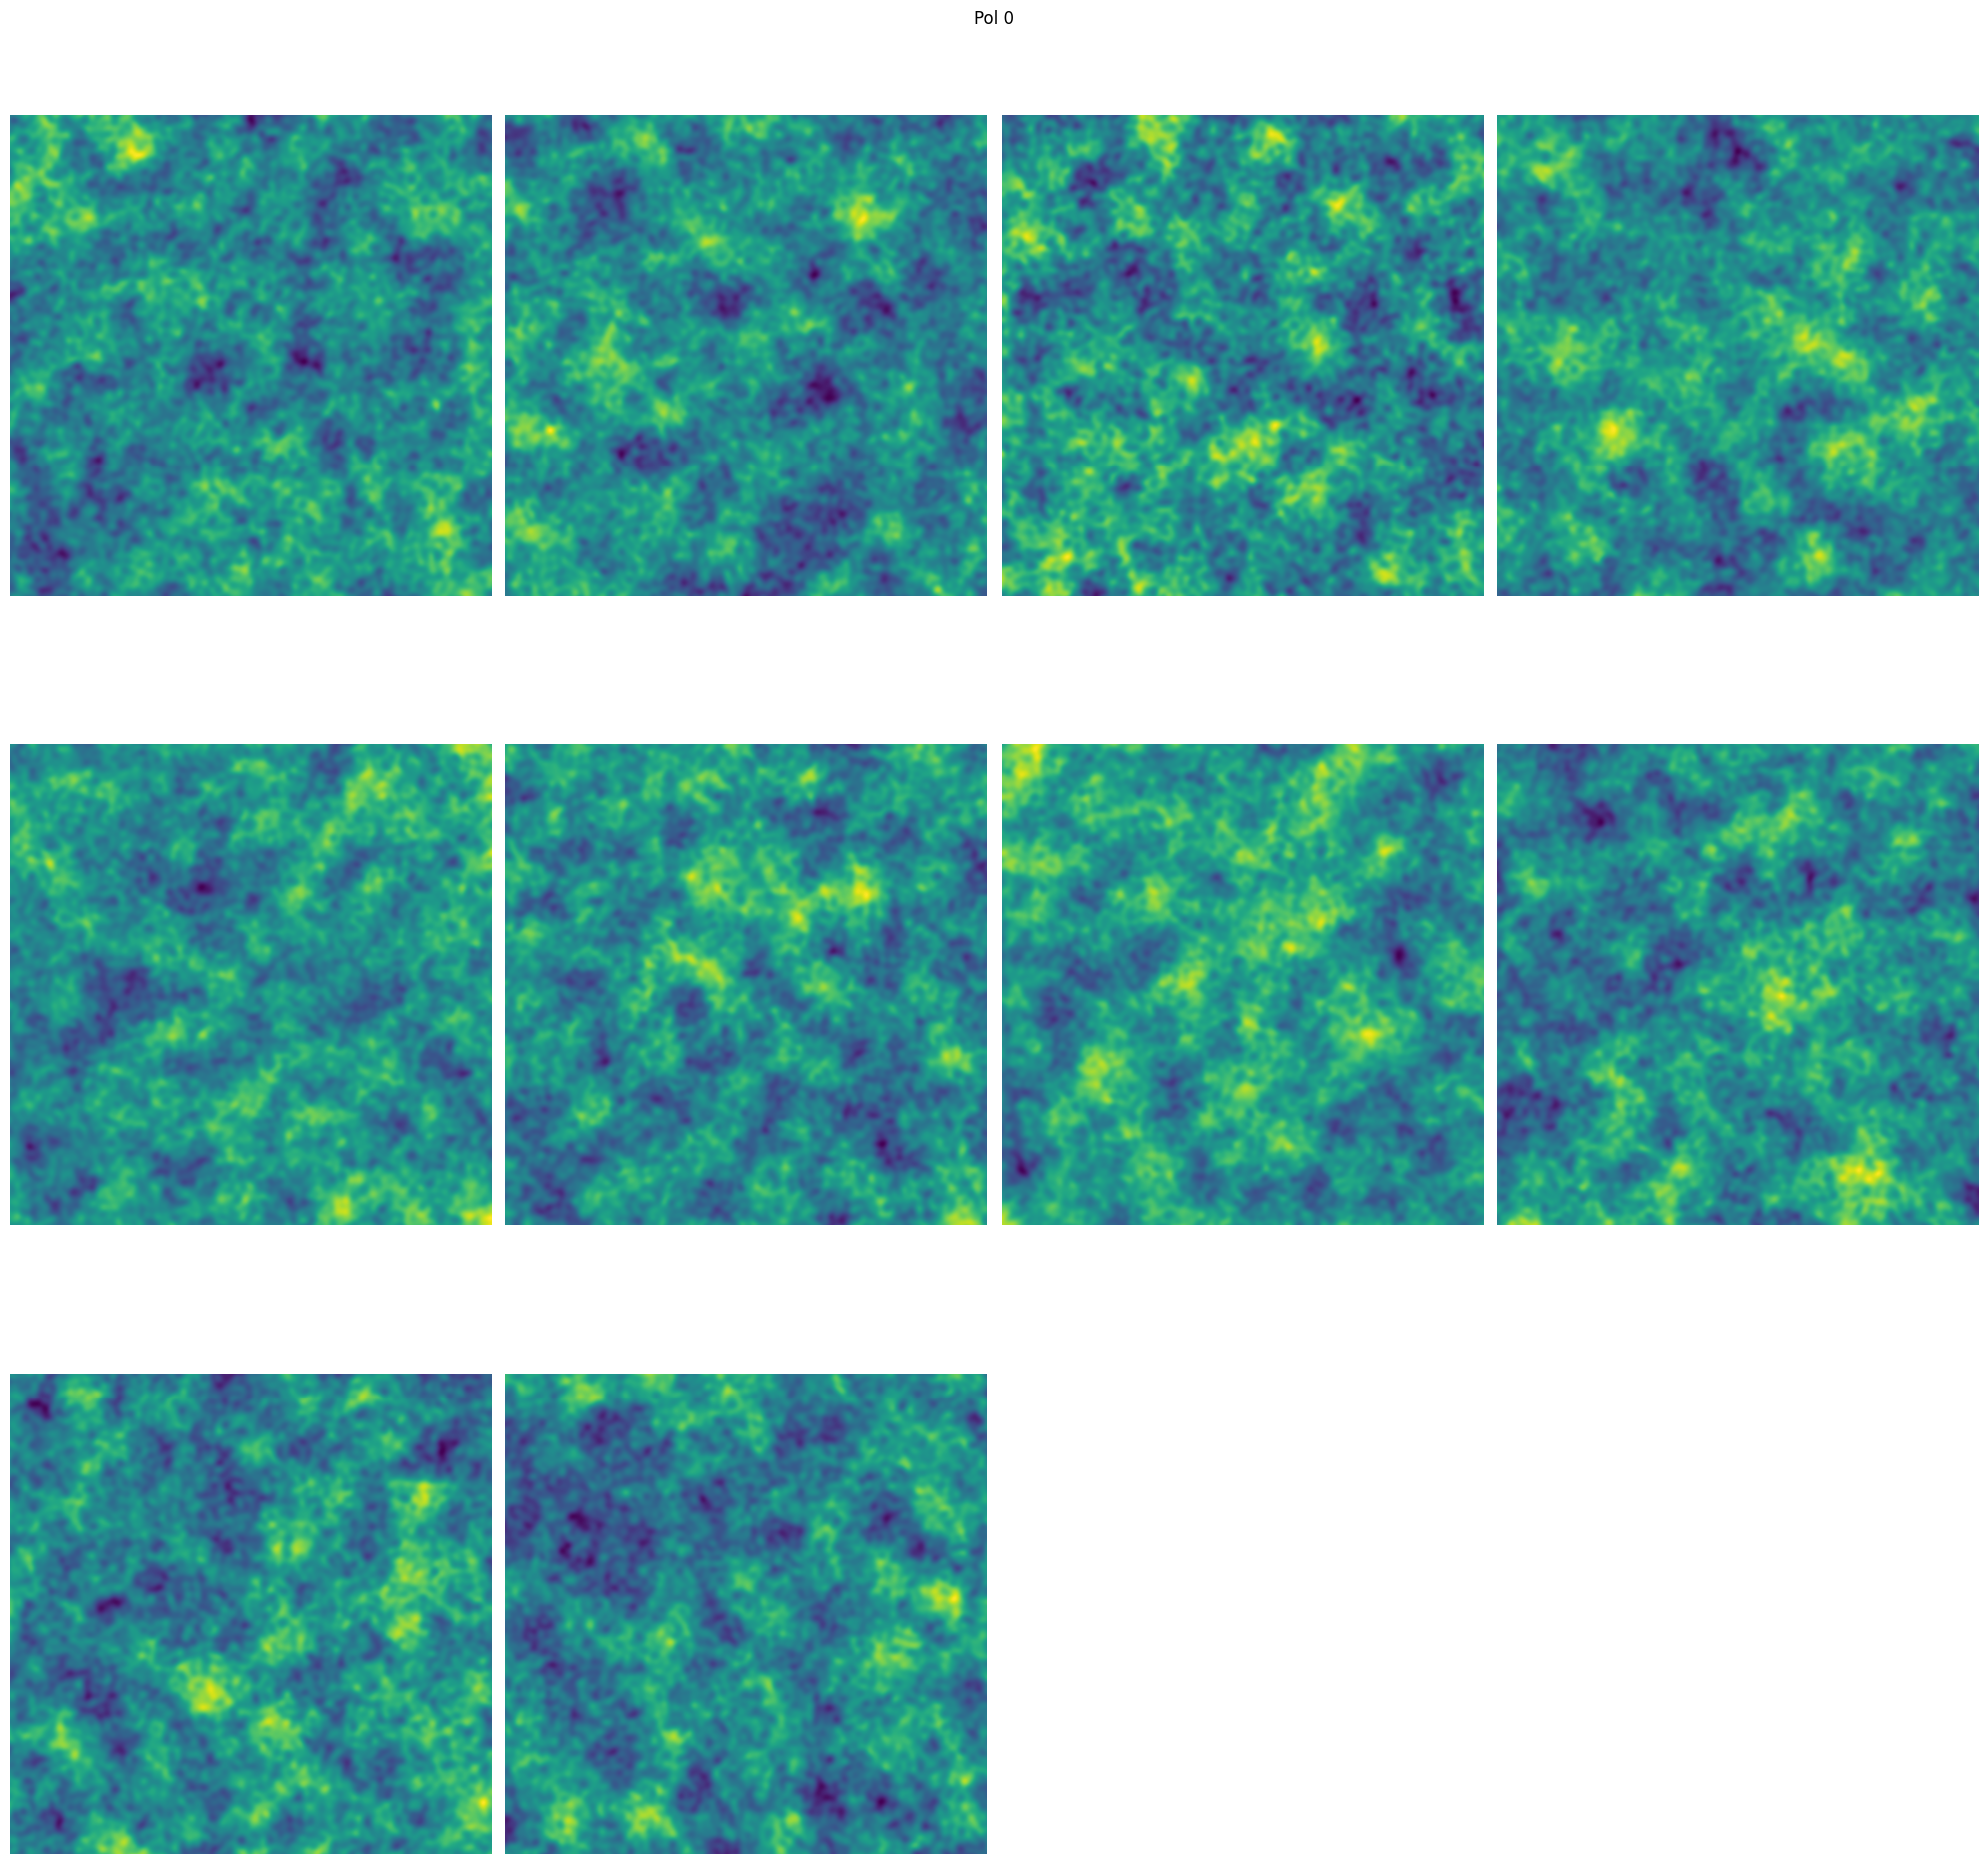

In [10]:
for pol in range(s.npol):
    plot_patches(patches[0, pol], 10, title=f"Pol {pol}")

## Estimator

In [11]:
def alm_step_loader(idx):
    logger.info("Running KSW step %s", idx)
    return s.data.compute_alm_sim(s.lensing)


theta_batch = int(np.floor(1.5 * s.lmax + 1)) // s.scpus
logger.info("Running KSW step with %s threads", s.scpus)
s.ksw.step_batch(alm_step_loader, range(100), theta_batch=theta_batch)

24-Apr-24 14:54:50 - __main__ - INFO - Running KSW step with 64 threads                             ]8;id=673199;file:///tmp/ipykernel_2449164/1737517589.py\1737517589.py]8;;\:]8;id=378885;file:///tmp/ipykernel_2449164/1737517589.py#7\7]8;;\

24-Apr-24 14:54:50 - notebooks.ksw_joblib - INFO - processing 0                                   ]8;id=587744;file:///users/stevensonb/Research/MLPNG/notebooks/ksw_joblib.py\ksw_joblib.py]8;;\:]8;id=643047;file:///users/stevensonb/Research/MLPNG/notebooks/ksw_joblib.py#128\128]8;;\

24-Apr-24 14:54:50 - __main__ - INFO - Running KSW step 0                                           ]8;id=537940;file:///tmp/ipykernel_2449164/1737517589.py\1737517589.py]8;;\:]8;id=389908;file:///tmp/ipykernel_2449164/1737517589.py#2\2]8;;\

24-Apr-24 14:57:05 - notebooks.ksw_joblib - INFO - processing 1                                   ]8;id=843909;file:///users/stevensonb/Research/MLPNG/notebooks/ksw_joblib.py\ksw_joblib.py]8;;\:]8;id=317685;file:///users/stevensonb/Research/MLPNG/notebooks/ksw_joblib.py#128\128]8;;\

24-Apr-24 14:57:05 - __main__ - INFO - Running KSW step 1                                           ]8;id=606972;file:///tmp/ipykernel_2449164/1737517589.py\1737517589.py]8;;\:]8;id=14270;file:///tmp/ipykernel_2449164/1737517589.py#2\2]8;;\

In [ ]:
fisher = float(s.ksw.compute_fisher())
print(fisher)
logger.info("Fisher: %s, standard deviation: %s", fisher, np.sqrt(1 / fisher))

In [ ]:
def alm_loader(i):
    logger.info("Loading alm %s, FNL %s", i, fnls[i, 0])
    return alms[i, 0]


idxs = range(alms.shape[0])
estimates = s.ksw.compute_estimate_batch(
    alm_loader, idxs, theta_batch=theta_batch, fisher=fisher
)